# Detecting Boundaries and Teleconnections via Contrasting Euclidean Distance Against Spatial Similarities

## Preliminaries

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

cpu


In [2]:
puck_list = 'all'
# gene_list = [ "Inha", "Inhba", "Inhbb", "Fst"]
gene_list = [ "Inha", "Inhba", "Inhbb", "Fst", "Esr1", "Esr2", "Pgr", "Ar", "Cyp19a1", 
    "Cyp17a1", "Cyp11a1", "Lhcgr", "Parm1", "Akr1c18", "Fshr", "Star", "Ptgfr", 
    "Sfrp4", "Acvr1", "Acvr2a", "Acvr2b", "Ghr", "Lhb", "Cga"]
head = 5000
adata, X, Y, df=load_data(gene_list=gene_list, head=head, puck_list = puck_list)
X

tensor([[ 0.1104, -0.0827],
        [ 0.0729, -0.0956],
        [-0.1857,  0.0859],
        ...,
        [ 0.0027, -0.0081],
        [ 0.0625,  0.4555],
        [-0.0133, -0.2196]], dtype=torch.float64)

In [3]:
Y

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64)

In [4]:
import numpy as np
import torch
from scipy.spatial.distance import pdist, squareform
from collections import Counter
import matplotlib.pyplot as plt
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Function to compute pairwise distances
def compute_distances(X):
    logging.info("Computing pairwise distances.")
    distances = squareform(pdist(X.numpy()))
    return distances

# Function to get indices of pairs within an interval cutoff
def get_close_pairs(distances, percentage=0.05):
    logging.info(f"Identifying pairs within the distance cutoff for the smallest {percentage * 100}%.")
    sorted_distances = np.sort(distances.flatten())
    cutoff = sorted_distances[int(percentage * len(sorted_distances))]
    close_pair_indices = np.argwhere(distances <= cutoff)
    return close_pair_indices, cutoff

# Function to get indices of pairs for teleconnections (largest distances)
def get_far_pairs(distances, percentage=0.05):
    logging.info(f"Identifying pairs within the largest {percentage * 100}% of distances.")
    sorted_distances = np.sort(distances.flatten())
    cutoff = sorted_distances[int((1 - percentage) * len(sorted_distances))]
    far_pair_indices = np.argwhere(distances >= cutoff)
    return far_pair_indices, cutoff

# Function to compute variances for pairs
def compute_variances(pair_indices, distances, Y):
    logging.info("Computing variances for pairs.")
    variances = []
    index_pairs = []
    for i, j in pair_indices:
        if i < j:
            diff = Y[i] - Y[j]
            var = torch.var(diff).item()
            variances.append(var)
            index_pairs.append((i, j))
    return variances, index_pairs

# Function to get top variance pairs
def get_top_variance_pairs(variances, index_pairs, percentage=0.05, find_top=True):
    logging.info(f"Identifying top {percentage * 100}% variance pairs.")
    sorted_indices = np.argsort(variances)[-int(percentage * len(variances)):] if find_top else np.argsort(variances)[:int(percentage * len(variances))]
    top_pairs = [index_pairs[k] for k in sorted_indices]
    return top_pairs

# Function to adaptively calculate dot size for scatterplots
def calculate_dot_size(num_points, base_size=30):
    max_points = 5000  # Threshold for reducing dot size
    if num_points > max_points:
        return max(base_size / (num_points / max_points), 1) * 0.1
    return base_size

# Function to plot histogram of variances
def plot_variance_histogram(variances, title, percentage, cutoff=None):
    logging.info("Plotting histogram of variances.")
    plt.figure(figsize=(8, 6))
    plt.hist(variances, bins=50, edgecolor="black", alpha=0.7, label="Empirical Variances")
    plt.yscale('log')
    if cutoff is not None:
        plt.axvline(x=cutoff, color='red', linestyle='--', label=f'Threshold at {percentage * 100}%')
    plt.xlabel("Empirical Variance")
    plt.ylabel("Frequency")
    plt.title(f"{title} (Threshold: {percentage * 100}%)")
    plt.legend()
    plt.grid()
    plt.show()

# Function to analyze and plot top frequent cells
def analyze_top_frequent_cells(top_variance_pairs, X, title, percentage):
    logging.info("Analyzing top frequent cells.")
    flattened_indices = [index for pair in top_variance_pairs for index in pair]
    cell_frequencies = Counter(flattened_indices)
    sorted_frequencies = sorted(cell_frequencies.items(), key=lambda x: x[1], reverse=True)
    top_cutoff = max(1, int(percentage * len(sorted_frequencies)))
    top_cells = sorted_frequencies[:top_cutoff]

    logging.info(f"Top {percentage * 100}% most frequent cells:")
    for cell, freq in top_cells:
        logging.info(f"Cell {cell}: {freq} occurrences")

    top_indices = [cell for cell, _ in top_cells]
    top_coords = X[top_indices]

    dot_size = calculate_dot_size(X.shape[0])

    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], color="lightgray", s=dot_size, label="All Cells")
    plt.scatter(top_coords[:, 0], top_coords[:, 1], color="red", s=dot_size * 1.5, label=f"Top {percentage * 100}% Most Frequent Cells")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title(f"{title} (Threshold: {percentage * 100}%)")
    plt.legend()
    plt.grid()
    plt.show()

    return top_indices

# Function to plot cell connections
def plot_cell_connections(X, top_indices, top_variance_pairs, title_prefix):
    dot_size = calculate_dot_size(X.shape[0])
    for cell_idx in top_indices:
        logging.info(f"Plotting connections for cell {cell_idx}.")
        connected_cells = set()

        for pair in top_variance_pairs:
            if cell_idx in pair:
                connected_cells.add(pair[0] if pair[1] == cell_idx else pair[1])

        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], color="lightgray", s=dot_size, label="All Cells")
        plt.scatter(X[cell_idx, 0], X[cell_idx, 1], color="red", s=dot_size * 1.5, label="Highlighted Cell", zorder=3)
        plt.scatter(X[list(connected_cells), 0], X[list(connected_cells), 1], color="blue", s=dot_size, label="Connected Cells", zorder=2)

        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.title(f"{title_prefix} Connections for Cell {cell_idx}")
        plt.legend()
        plt.grid()
        plt.show()

## Main workflow for boundary detection

2025-01-26 00:35:36,103 - INFO - Starting boundary detection analysis.
2025-01-26 00:35:36,103 - INFO - Computing pairwise distances.
2025-01-26 00:35:36,184 - INFO - Identifying pairs within the distance cutoff for the smallest 0.5%.
2025-01-26 00:35:36,535 - INFO - Computing variances for pairs.
2025-01-26 00:35:37,128 - INFO - Identifying top 0.5% variance pairs.
2025-01-26 00:35:37,131 - INFO - Plotting histogram of variances.


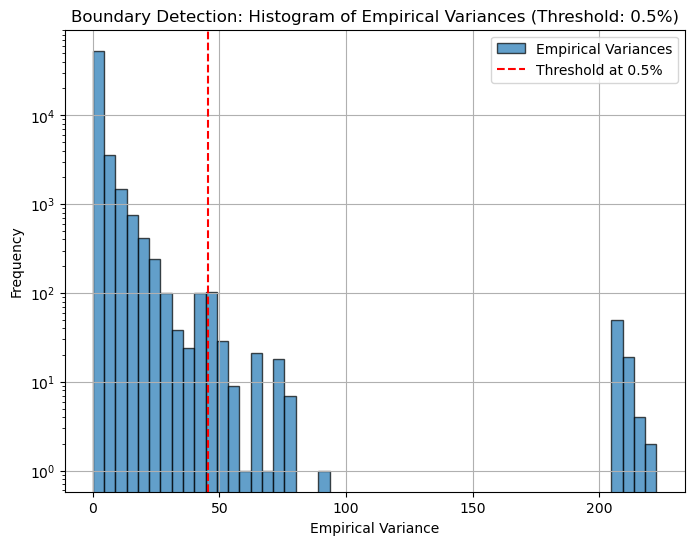

In [ ]:
percentage_histogram_threshold = 0.005  # Default for plot_variance_histogram
percentage_frequent_cells_threshold = 0.05  # Default for analyze_top_frequent_cells  # Default threshold value
logging.info("Starting boundary detection analysis.")
distances = compute_distances(X)
close_pair_indices, boundary_cutoff = get_close_pairs(distances, percentage=percentage_histogram_threshold)
variances, index_pairs = compute_variances(close_pair_indices, distances, Y)
top_variance_pairs = get_top_variance_pairs(variances, index_pairs, percentage=percentage_histogram_threshold, find_top=True)
plot_variance_histogram(variances, "Boundary Detection: Histogram of Empirical Variances", percentage_histogram_threshold, cutoff=max(variances[-int(percentage_histogram_threshold * len(variances)):]))

2025-01-26 00:35:37,427 - INFO - Analyzing top frequent cells.
2025-01-26 00:35:37,428 - INFO - Top 5.0% most frequent cells:
2025-01-26 00:35:37,428 - INFO - Cell 2448: 47 occurrences
2025-01-26 00:35:37,428 - INFO - Cell 349: 41 occurrences
2025-01-26 00:35:37,428 - INFO - Cell 56: 39 occurrences
2025-01-26 00:35:37,429 - INFO - Cell 345: 35 occurrences
2025-01-26 00:35:37,429 - INFO - Cell 199: 31 occurrences
2025-01-26 00:35:37,429 - INFO - Cell 3282: 28 occurrences
2025-01-26 00:35:37,429 - INFO - Cell 2564: 25 occurrences
2025-01-26 00:35:37,429 - INFO - Cell 3309: 18 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 4866: 17 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 1290: 16 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 3459: 1 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 3564: 1 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 3795: 1 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 1339: 1 occurrences
2025-01-26 00:35:37,430 - INFO - Cell 1391: 1 occurrences

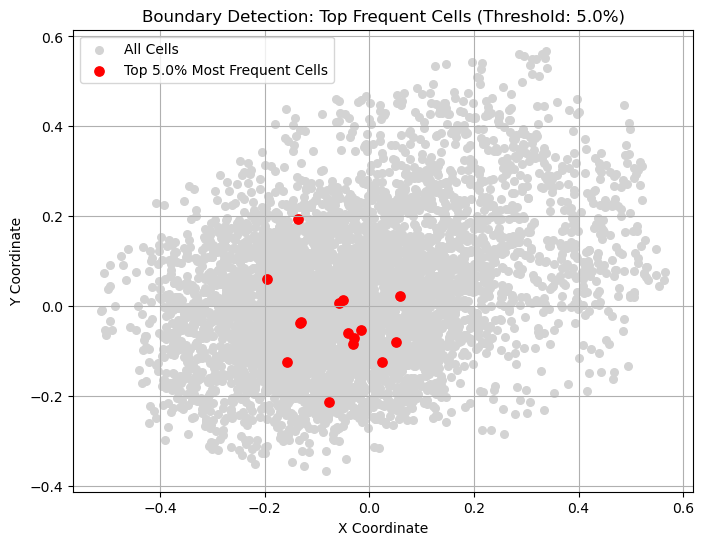

In [6]:
top_indices = analyze_top_frequent_cells(top_variance_pairs, X, "Boundary Detection: Top Frequent Cells", percentage_frequent_cells_threshold)

2025-01-26 00:35:37,562 - INFO - Plotting connections for cell 2448.


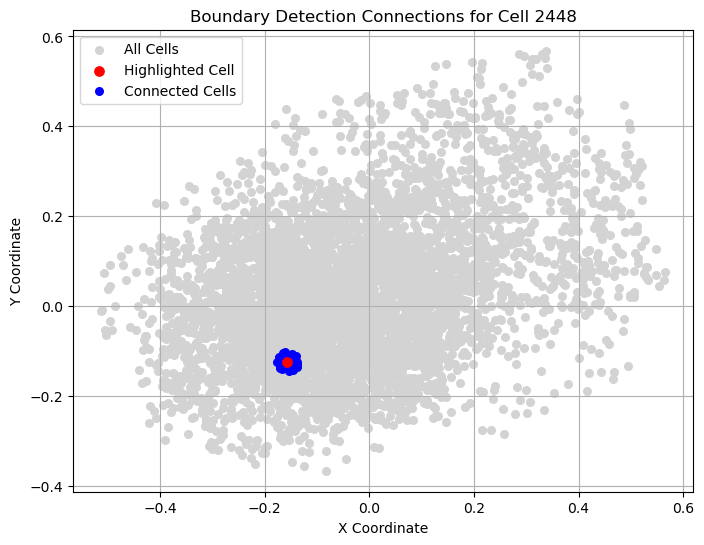

2025-01-26 00:35:37,696 - INFO - Plotting connections for cell 349.


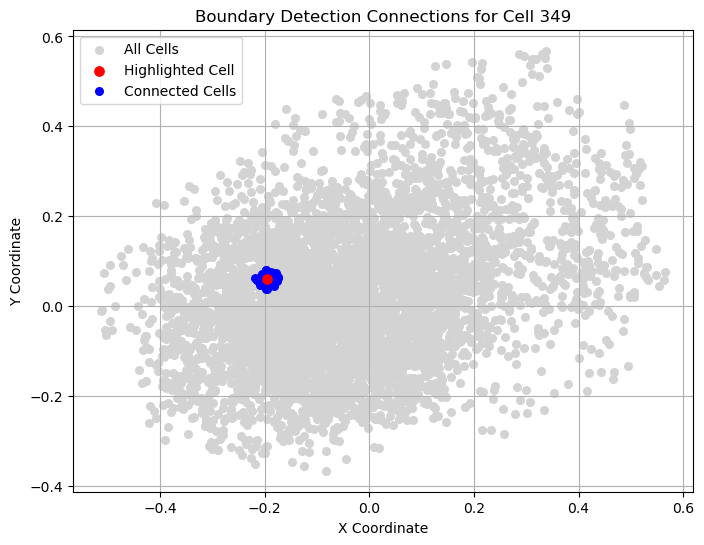

2025-01-26 00:35:37,829 - INFO - Plotting connections for cell 56.


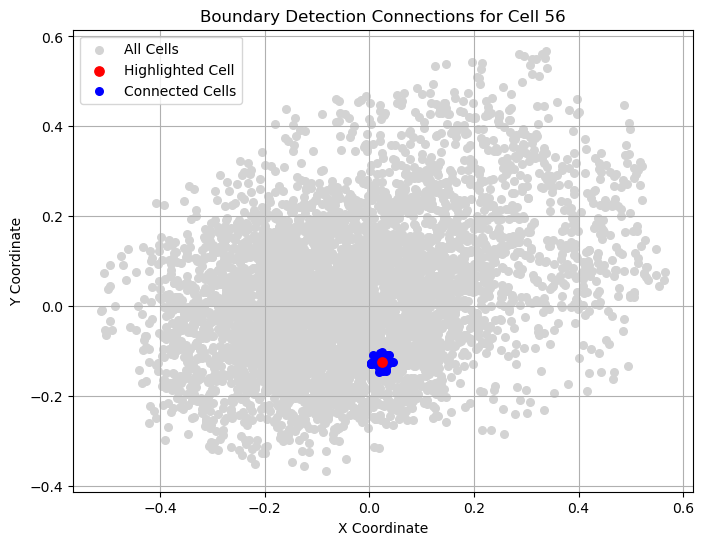

2025-01-26 00:35:38,053 - INFO - Plotting connections for cell 345.


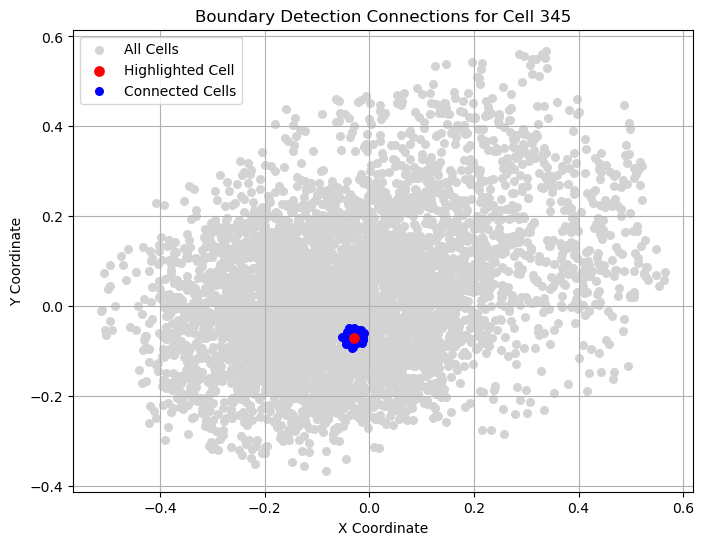

2025-01-26 00:35:38,187 - INFO - Plotting connections for cell 199.


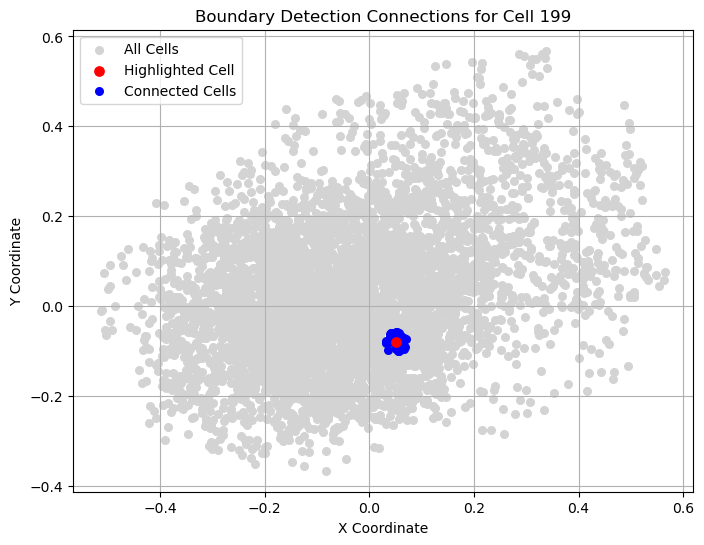

2025-01-26 00:35:38,321 - INFO - Plotting connections for cell 3282.


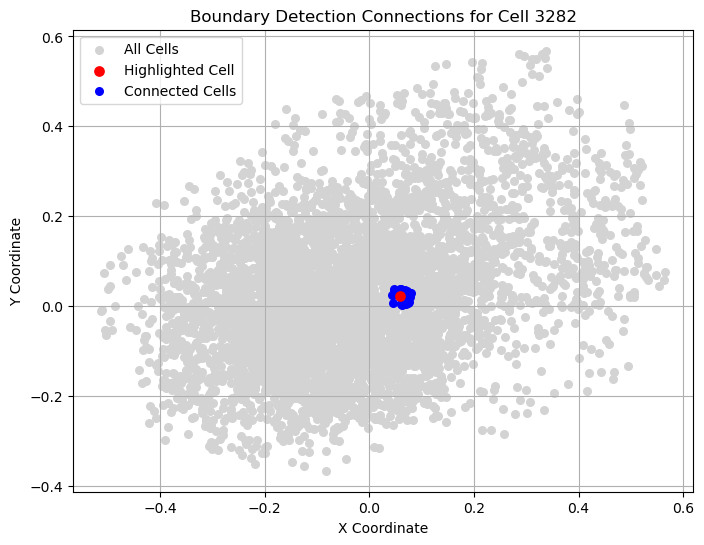

2025-01-26 00:35:38,455 - INFO - Plotting connections for cell 2564.


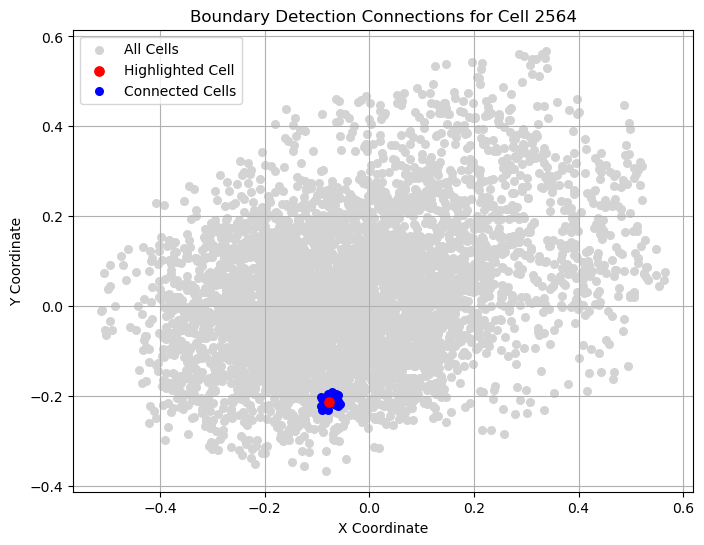

2025-01-26 00:35:38,589 - INFO - Plotting connections for cell 3309.


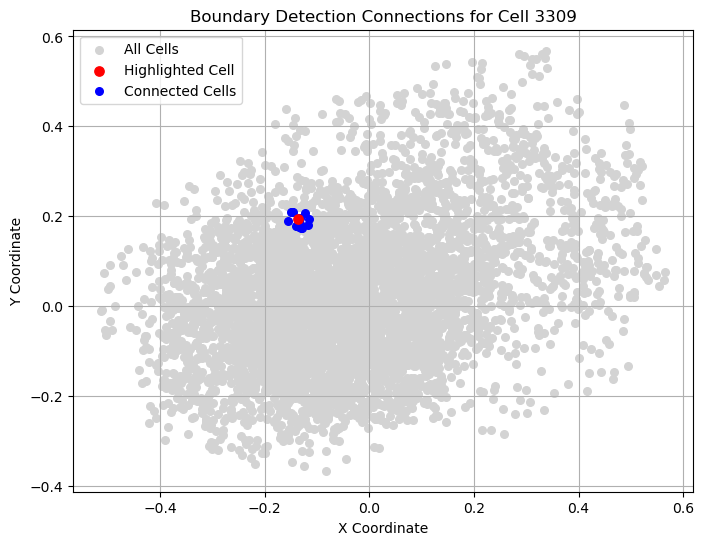

2025-01-26 00:35:38,722 - INFO - Plotting connections for cell 4866.


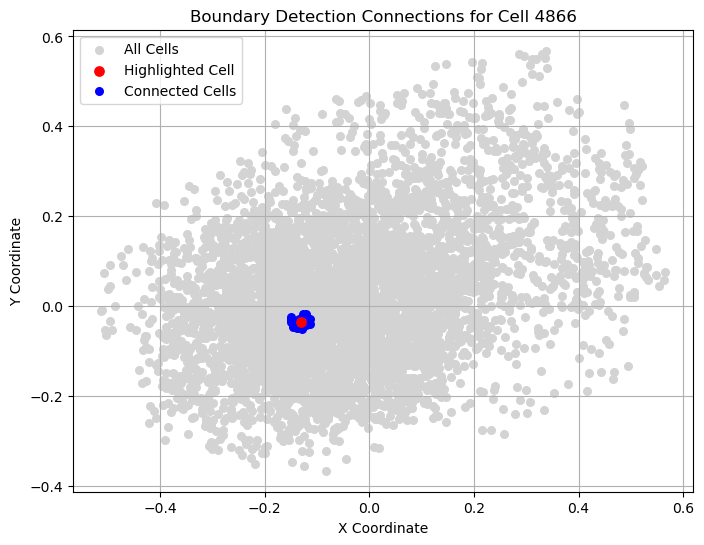

2025-01-26 00:35:38,855 - INFO - Plotting connections for cell 1290.


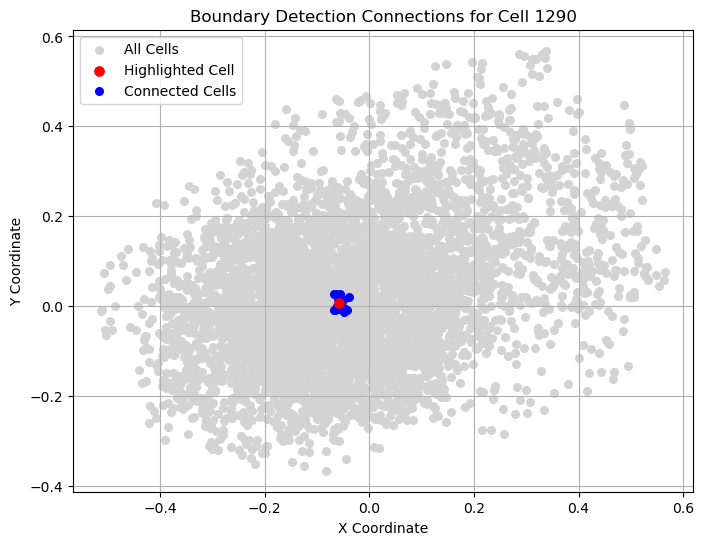

2025-01-26 00:35:38,988 - INFO - Plotting connections for cell 3459.


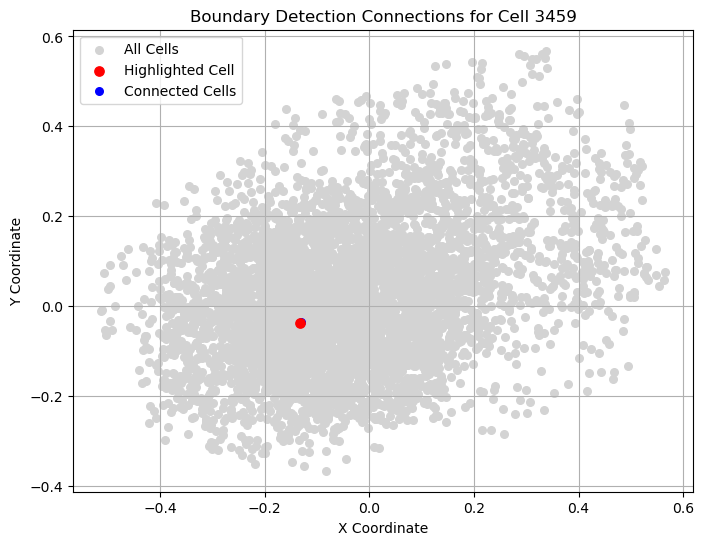

2025-01-26 00:35:39,120 - INFO - Plotting connections for cell 3564.


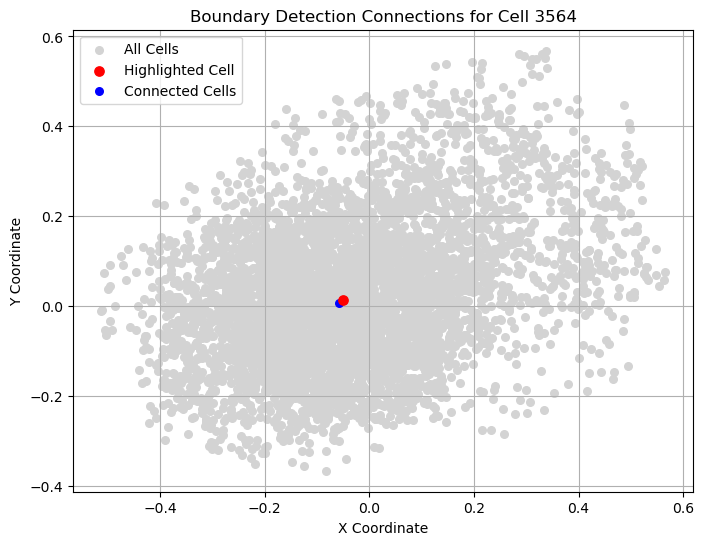

2025-01-26 00:35:39,252 - INFO - Plotting connections for cell 3795.


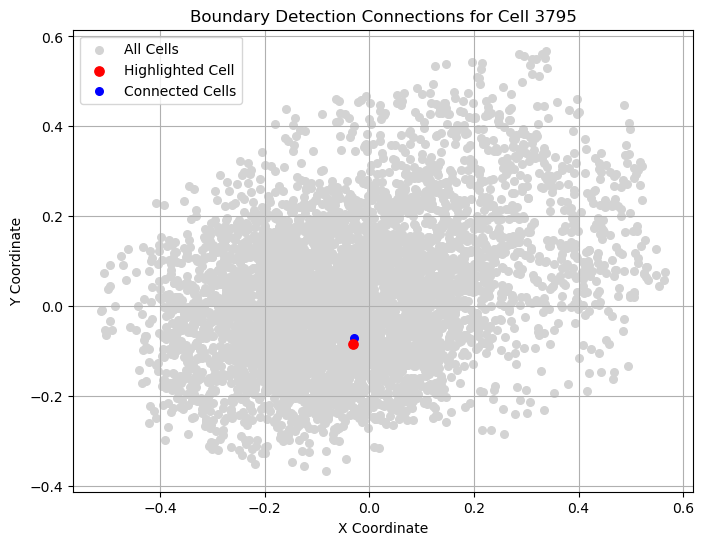

2025-01-26 00:35:39,385 - INFO - Plotting connections for cell 1339.


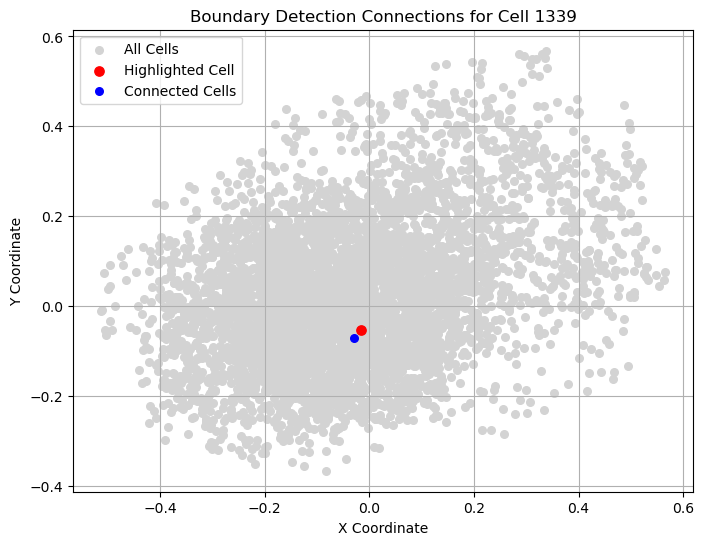

2025-01-26 00:35:39,516 - INFO - Plotting connections for cell 1391.


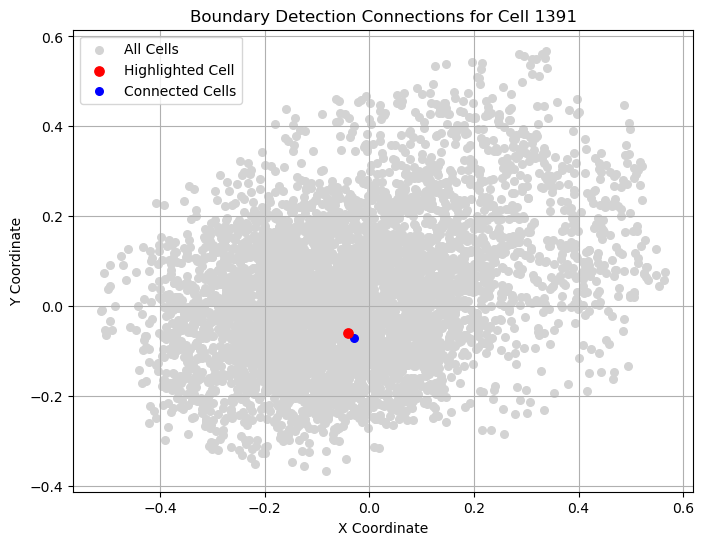

2025-01-26 00:35:39,735 - INFO - Boundary detection analysis complete.


In [7]:
plot_cell_connections(X, top_indices, top_variance_pairs, "Boundary Detection")
logging.info("Boundary detection analysis complete.")

## Main workflow for teleconnection detection

2025-01-26 00:35:39,738 - INFO - Starting teleconnection detection analysis.
2025-01-26 00:35:39,738 - INFO - Identifying pairs within the largest 0.5% of distances.
2025-01-26 00:35:40,091 - INFO - Computing variances for pairs.
2025-01-26 00:35:40,707 - INFO - Identifying top 0.5% variance pairs.
2025-01-26 00:35:40,710 - INFO - Plotting histogram of variances.


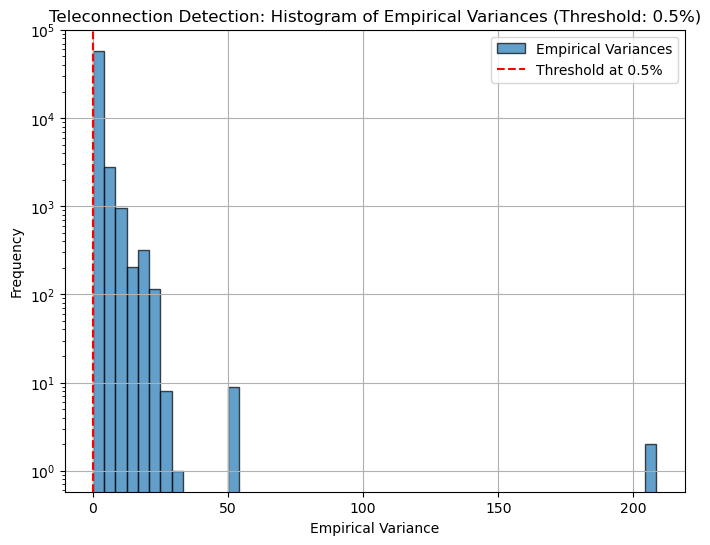

In [ ]:
logging.info("Starting teleconnection detection analysis.")
far_pair_indices, teleconnection_cutoff = get_far_pairs(distances, percentage=percentage_histogram_threshold)
variances, index_pairs = compute_variances(far_pair_indices, distances, Y)
top_variance_pairs = get_top_variance_pairs(variances, index_pairs, percentage=percentage_histogram_threshold, find_top=False)
plot_variance_histogram(variances, "Teleconnection Detection: Histogram of Empirical Variances", percentage_histogram_threshold, cutoff=min(variances[:int(percentage_histogram_threshold * len(variances))]))

2025-01-26 00:35:40,977 - INFO - Analyzing top frequent cells.
2025-01-26 00:35:40,977 - INFO - Top 5.0% most frequent cells:
2025-01-26 00:35:40,978 - INFO - Cell 1541: 47 occurrences
2025-01-26 00:35:40,978 - INFO - Cell 495: 42 occurrences
2025-01-26 00:35:40,978 - INFO - Cell 3225: 22 occurrences
2025-01-26 00:35:40,978 - INFO - Cell 140: 21 occurrences
2025-01-26 00:35:40,978 - INFO - Cell 1969: 15 occurrences
2025-01-26 00:35:40,978 - INFO - Cell 2600: 14 occurrences
2025-01-26 00:35:40,979 - INFO - Cell 1297: 14 occurrences
2025-01-26 00:35:40,979 - INFO - Cell 2344: 14 occurrences
2025-01-26 00:35:40,979 - INFO - Cell 2512: 11 occurrences
2025-01-26 00:35:40,979 - INFO - Cell 1050: 10 occurrences


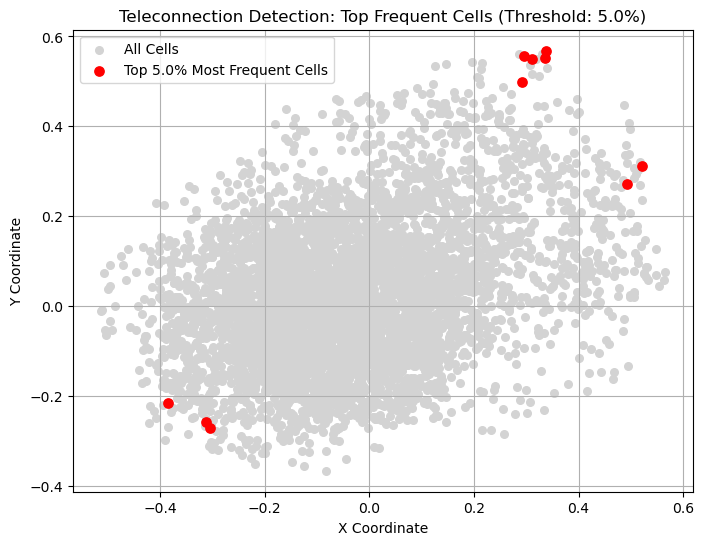

In [9]:
top_indices = analyze_top_frequent_cells(top_variance_pairs, X, "Teleconnection Detection: Top Frequent Cells", percentage_frequent_cells_threshold)

2025-01-26 00:35:41,109 - INFO - Plotting connections for cell 1541.


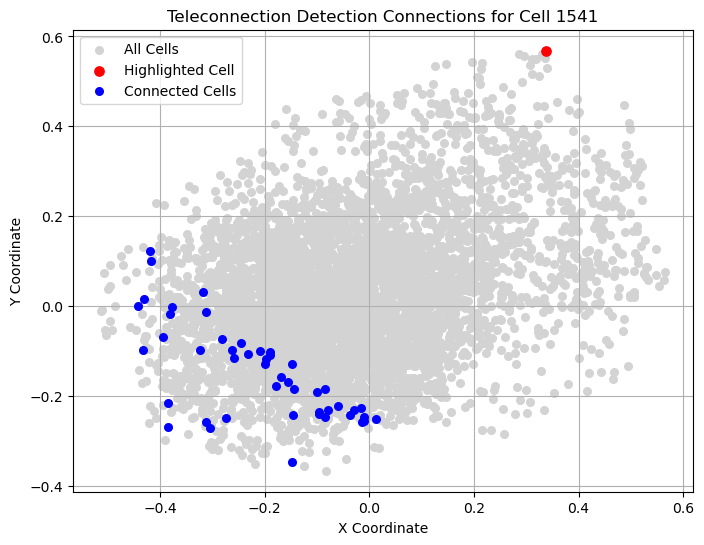

2025-01-26 00:35:41,245 - INFO - Plotting connections for cell 495.


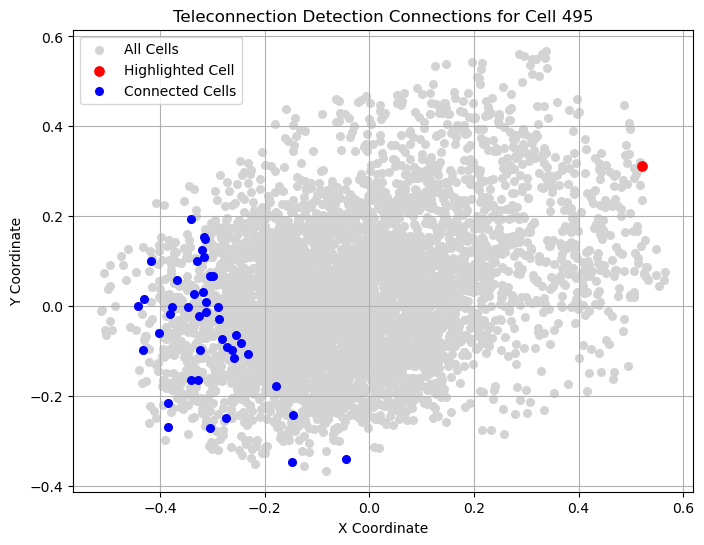

2025-01-26 00:35:41,379 - INFO - Plotting connections for cell 3225.


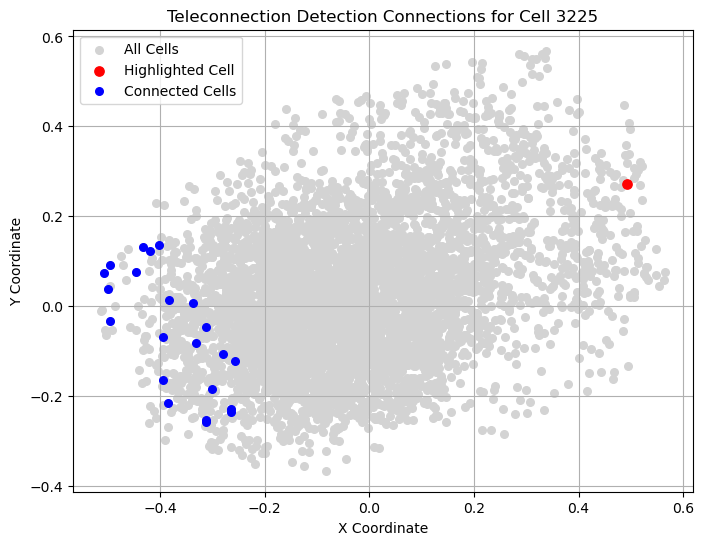

2025-01-26 00:35:41,512 - INFO - Plotting connections for cell 140.


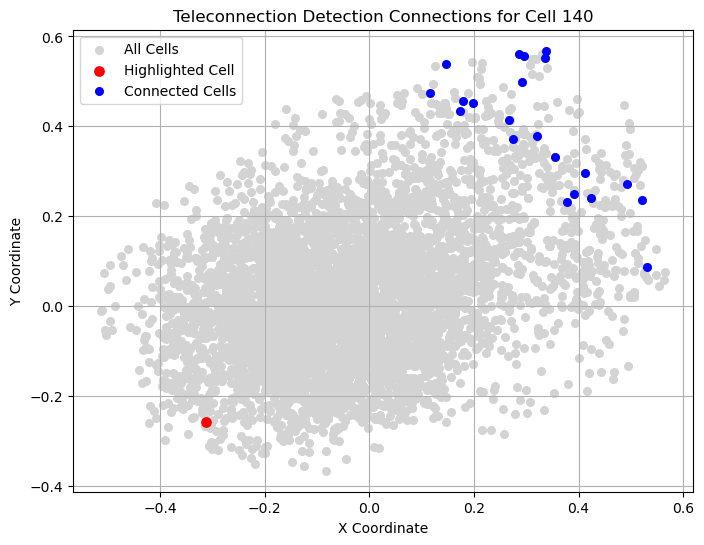

2025-01-26 00:35:41,645 - INFO - Plotting connections for cell 1969.


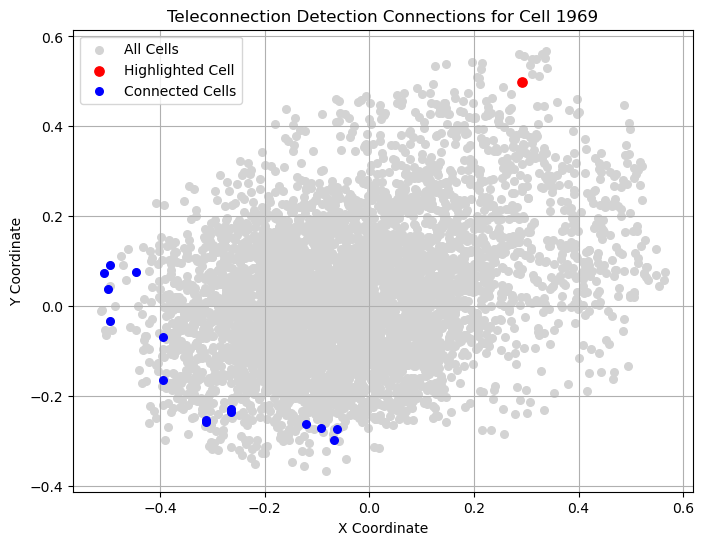

2025-01-26 00:35:41,778 - INFO - Plotting connections for cell 2600.


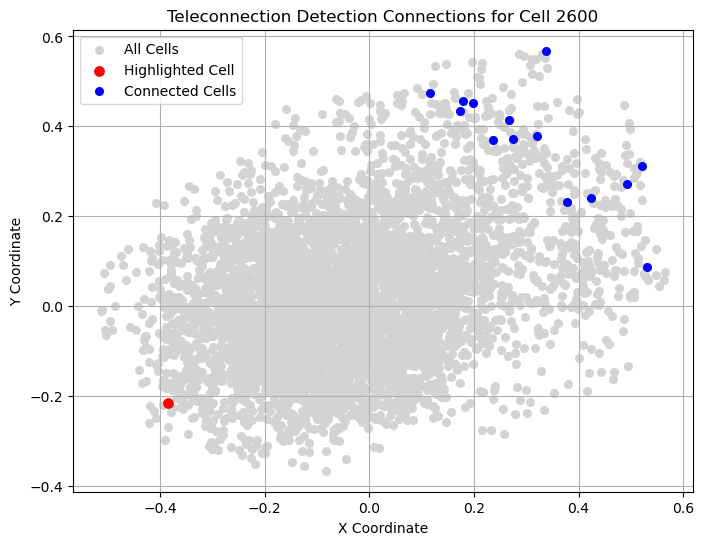

2025-01-26 00:35:41,911 - INFO - Plotting connections for cell 1297.


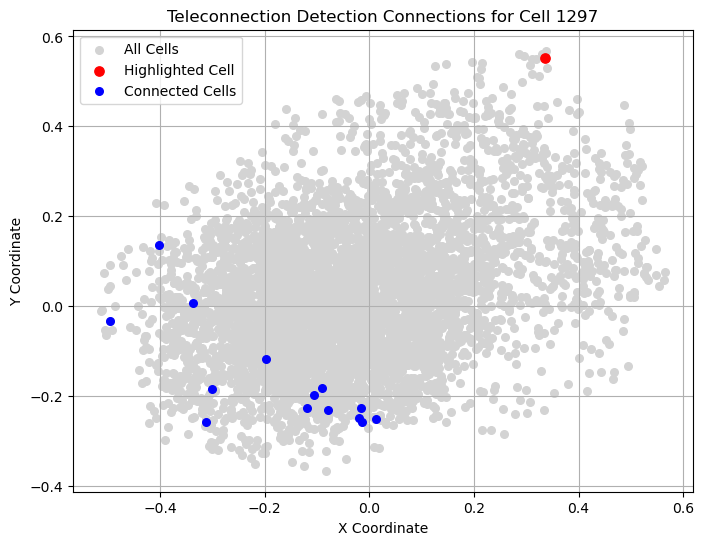

2025-01-26 00:35:42,043 - INFO - Plotting connections for cell 2344.


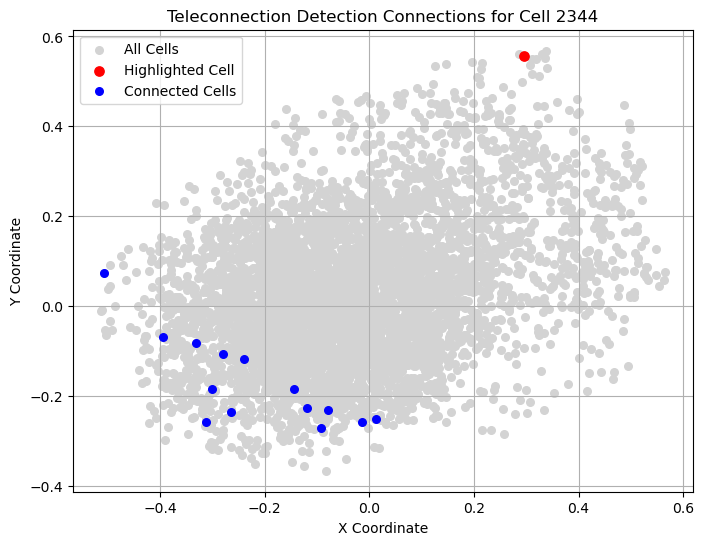

2025-01-26 00:35:42,175 - INFO - Plotting connections for cell 2512.


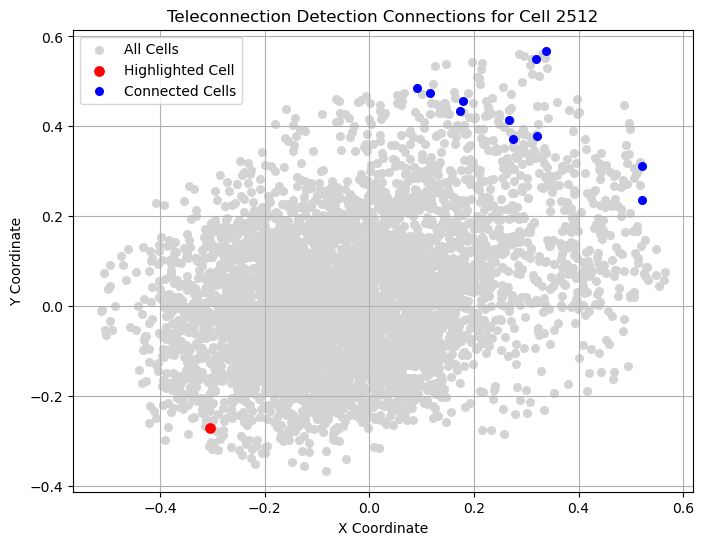

2025-01-26 00:35:42,307 - INFO - Plotting connections for cell 1050.


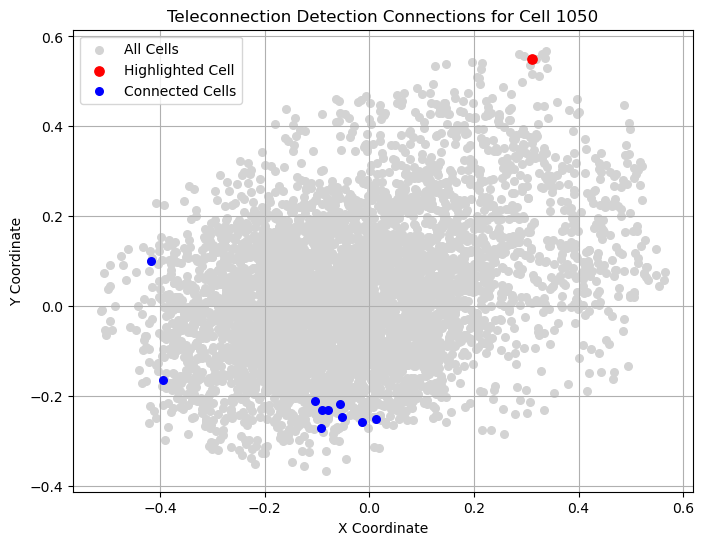

2025-01-26 00:35:42,536 - INFO - Teleconnection detection analysis complete.


In [10]:
plot_cell_connections(X, top_indices, top_variance_pairs, "Teleconnection Detection")
logging.info("Teleconnection detection analysis complete.")

## Some obvious problems
1. Boundary detection - the histogram is indeed bimodally distributed, and the cutoff threshold ought to be more adaptive.
2. Teleconnection detection - the histogram is in fact NOT bimodally distributed, so the cutoff seems simply arbitrary.
3. In teleconnection detection, perhaps only very faraway pairs are included.  Can relax this a little to get closer but not too closer pairs involved.
4. Perhaps some teleconnections do not indicate causally relevant pathways, but only similarity in cell types. 
5. Does not yet display the cell type and other information about these cells identified, so not sure what the Biological implications are. 

In [11]:
adata.obs.columns.tolist()

['n_genes',
 'n_genes_by_counts',
 'total_counts',
 'total_counts_mt',
 'pct_counts_mt',
 'puck',
 'Age',
 'n_counts',
 'leiden',
 'leiden_12',
 'cell_type',
 'leiden_15',
 'new_annot',
 'is_oocyte',
 'id_oocyte',
 'is_granulosa',
 'granulosa_type',
 'id_follicle',
 'id_corpusluteum',
 'id_proximity_oocyte',
 'id_proximity_follicle',
 'id_proximity_corpusluteum',
 'is_theca',
 'id_theca',
 'is_mesenchyme',
 'id_mesenchyme',
 'is_immune',
 'id_immune',
 'stromal_immune',
 'is_vascular',
 'id_vascular',
 'stromal_vascular',
 'is_epithelium',
 'id_epithelium',
 'is_primordial',
 'id_primordial',
 'oocyte_label',
 'new_annot_foll',
 'tissue',
 'mouse',
 'stage',
 'batch',
 'id_oocyte_matched',
 'segment_id',
 'segment_id_extended',
 'segment_layer',
 'segment_layer_extended',
 'segment_has_oocyte',
 'segment_label',
 'segment_label_coarse',
 'segment_type',
 'MNGC',
 'is_contaminant',
 'new_annot_foll_precontamination',
 'id_oocyte_precontamination',
 'id_oocyte_matched_precontamination',


In [12]:
adata.obs['new_annot_foll']

GACTAACNTGATCA-1-0         Luteal - early
GTCGCCCNTAAAGG-1-0                 Oocyte
TCCGAACTTGGTGG-1-0                 Oocyte
GTAGAGGACNTAAG-1-0                 Muscle
TAGNGCAGGGCTCC-1-0                 Oocyte
                             ...         
GGTTCCGCTGGTCG-1-1                Stromal
AATANCACTAACTG-1-1            Endothelial
ATAGGATTGCAGGT-1-1                 Immune
GGCTAATCGGCACC-1-1    GC - antral mitotic
TAATAATTTTCCGT-1-1             Epithelial
Name: new_annot_foll, Length: 201657, dtype: category
Categories (16, object): ['Cumulus - oocyte', 'Endothelial', 'Epithelial', 'GC - antral early mitotic', ..., 'Oocyte', 'Oocyte - contaminated', 'Stromal', 'Theca']

In [13]:
adata.obs['new_annot_foll'][adata.obs['new_annot_foll'] == "GC - atretic"]

TAGTCACCTCCCAC-1-0    GC - atretic
AGGAGGGCTGCACT-1-0    GC - atretic
TTGAGCGTTGCGAC-1-0    GC - atretic
CTTNCAAAAGACTT-1-0    GC - atretic
NATAGTNAGTAGGA-1-0    GC - atretic
                          ...     
GGTATCAACTAAAC-1-1    GC - atretic
TCAGGGGATAACAT-1-1    GC - atretic
TCCCAATCAGCTCA-1-1    GC - atretic
GCAGTNAGGGCACG-1-1    GC - atretic
AGCCGGTCCTCTAA-1-1    GC - atretic
Name: new_annot_foll, Length: 6095, dtype: category
Categories (16, object): ['Cumulus - oocyte', 'Endothelial', 'Epithelial', 'GC - antral early mitotic', ..., 'Oocyte', 'Oocyte - contaminated', 'Stromal', 'Theca']